In [3]:
import numpy as np
from matplotlib import pyplot as plt

import tensorflow as tf
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="tensorflow")

import keras
import sys
import os
import logging
import time
# Set TensorFlow logging level to ERROR
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
# Configure Python logging to suppress detailed Keras messages
logging.getLogger('tensorflow').setLevel(logging.ERROR)
import tensorflow as tf
import keras
import numpy as np
import datetime
from datetime import datetime
from packaging import version
import os

sys.path.append('../utils')
from Structure import *
from pathlib import Path
from module_utils import * 
from data_collection import *
# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)


True

In [5]:
tf.__version__

'2.17.0'

In [6]:
# introduction of a seed for reproducibility purposes
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

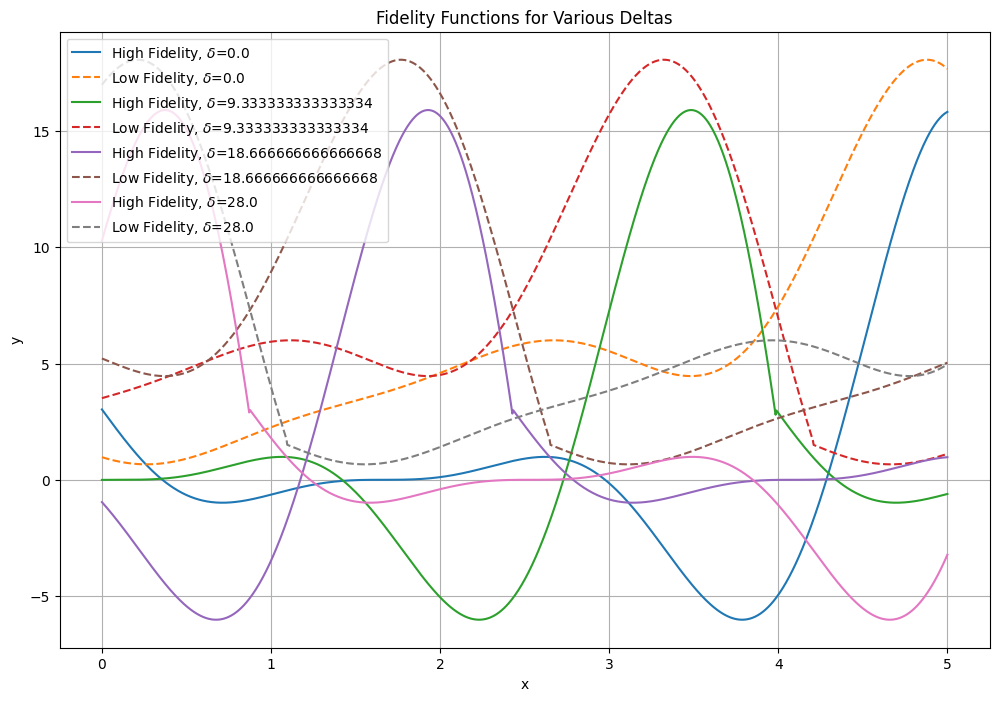

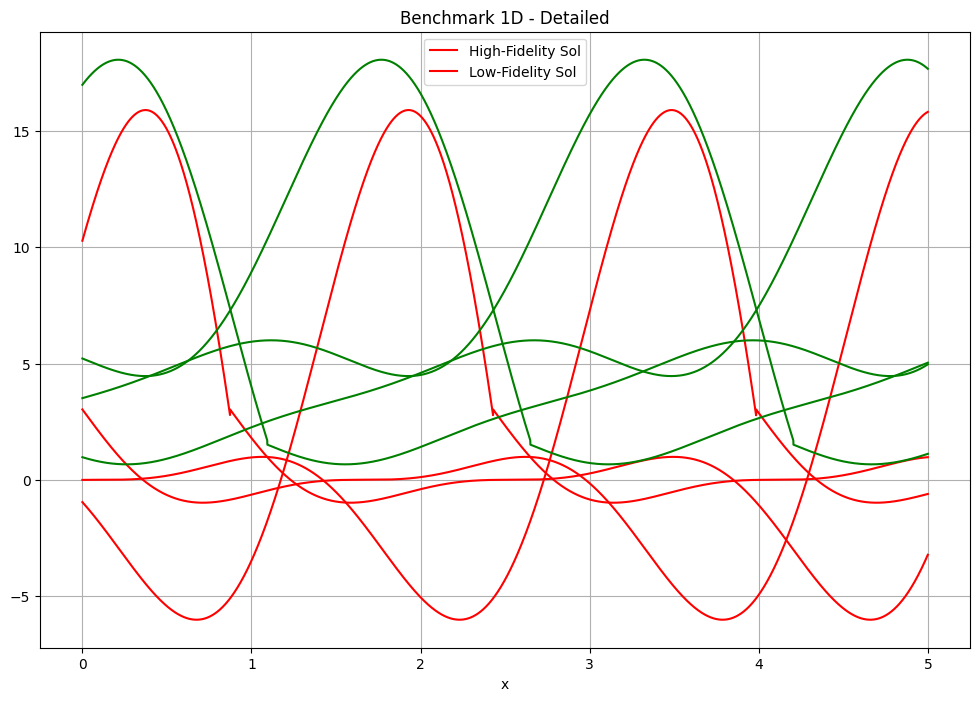

In [7]:
example = "Basic"
fidelity_func = FidelityFunctionModified(example)
fidelity_func.plot_functions()
fidelity_func.plot_detailed_functions()
data=fidelity_func.get_parameters(example)

In [8]:
np.unique(data["datatest"][:,1])

array([ 0.,  7., 14., 21., 28.])

The function training took 90.355213 seconds.


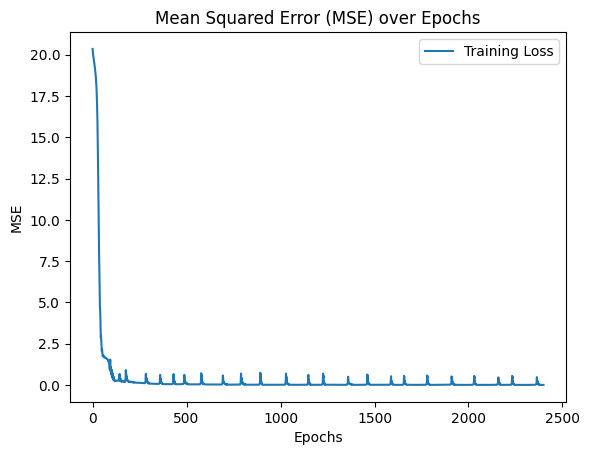

The function training took 75.031349 seconds.


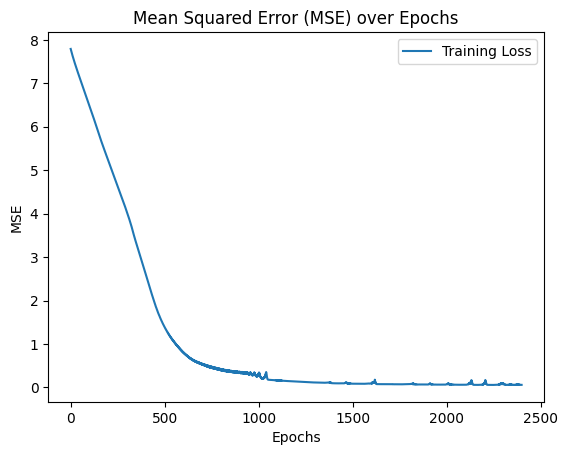

In [10]:
from tensorflow.keras.callbacks import TensorBoard
file_name='prova'
#logs = “logs/” + datetime.now().strftime(“%Y%m%d-%H%M%S”)
tboard_callback = TensorBoard(log_dir="logs\\{}".format(file_name))
final_model2 = NetworkFactory.build_network(**definition_2steps, profiler=tboard_callback)
                                          

In [12]:
import tensorflow as tf
import keras
import numpy as np
import datetime
from datetime import datetime
from packaging import version
import os

The function training took 7.219499 seconds.


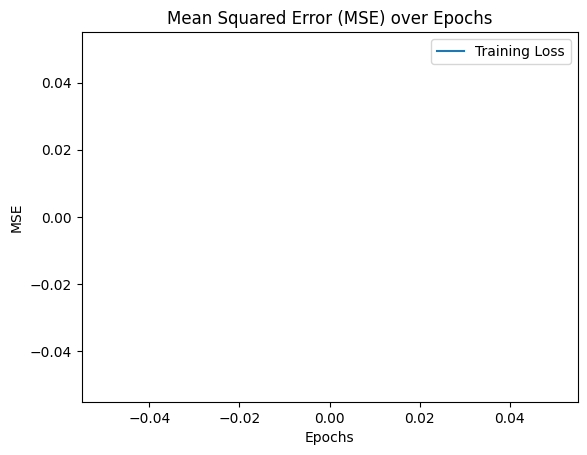

The function training took 4.183733 seconds.


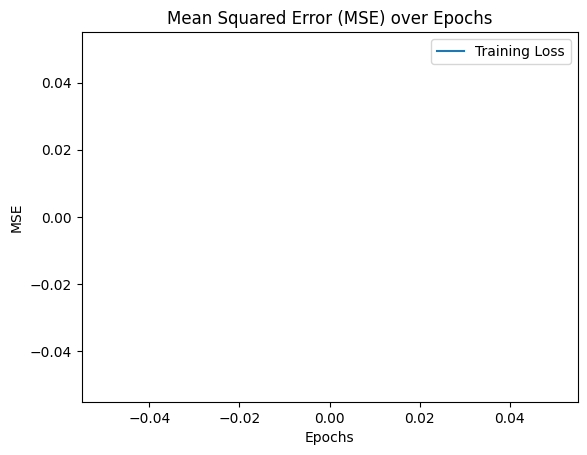

In [9]:
### 2 steps NEURAL NETWORK ###
# collection of parameters
bestLF_params = {'kernel_init': 'uniform',
 'l2weight': 0.016527415904907163,
 'lr': 0.004136213398097982,
 'nodes': 63,
 'opt': 'Adamax'}
best_params ={'kernel_init': 'glorot_uniform',
 'l2weight': 0.0007706688399557185,
 'lr': 0.007672132623001766,
 'nodes': 37,
 'opt': 'Adamax'}

params = [bestLF_params, best_params]

N = [100,100]
n = [data["Nlf"], data["Nhf"]]

# names of the networks 
names = ['LF', 'HF']

logs = "logs/" + datetime.now().strftime("%Y%m%d-%H%M%S")
tboard_callback = tf.keras.callbacks.TensorBoard(log_dir = logs, histogram_freq = 1, profile_batch = "1,2")

definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params,
    "data_train": [data["xlf"], data["xhf"]],
    "output_train": [data["Ylf"], data["Yhf"]],
    "data_val":[data["x_vallf"],data["x_valhf"]],
    "output_val":[data["dataval_lf"],data["dataval_hf"]],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": False,
    "verbose": False,
    "profiler":tboard_callback
}
final_model2 = NetworkFactory.build_network(**definition_2steps)



In [10]:
%load_ext tensorboard
%tensorboard --logdir=logs

Reusing TensorBoard on port 6006 (pid 1178072), started 1:06:17 ago. (Use '!kill 1178072' to kill it.)

The function training took 60.315434 seconds.


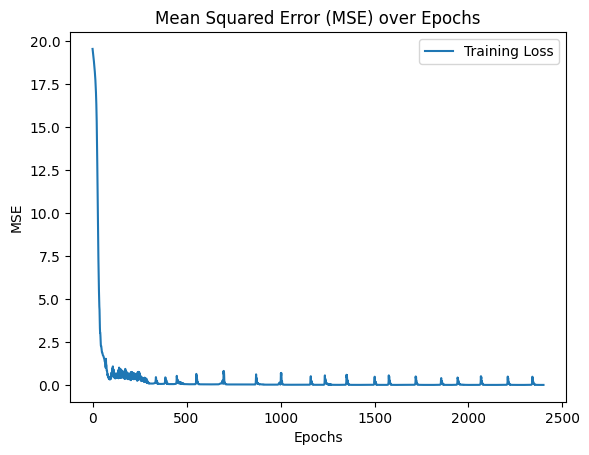

The function training took 69.103595 seconds.


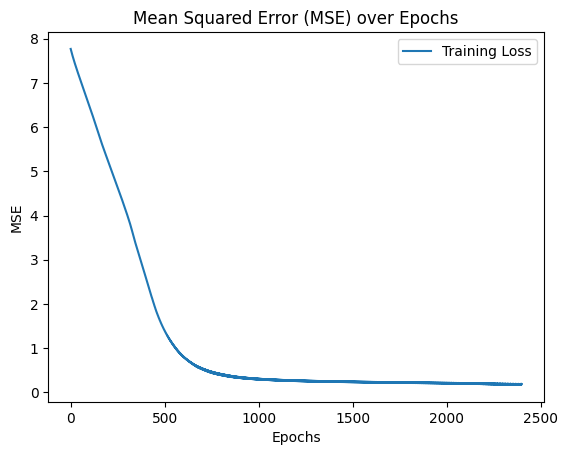

Test MSE: 1.2749497241782906
R^2: 0.9583834916988074


In [5]:
### 2 steps NEURAL NETWORK ###
# collection of parameters
bestLF_params = {'kernel_init': 'uniform',
 'l2weight': 0.016527415904907163,
 'lr': 0.004136213398097982,
 'nodes': 63,
 'opt': 'Adamax'}
best_params ={'kernel_init': 'glorot_uniform',
 'l2weight': 0.0007706688399557185,
 'lr': 0.007672132623001766,
 'nodes': 37,
 'opt': 'Adamax'}

params = [bestLF_params, best_params]

N = [data["NepoLF"], data["NepoHF"]]
n = [data["Nlf"], data["Nhf"]]

# names of the networks 
names = ['LF', 'HF']

# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params,
    "data_train": [data["xlf"], data["xhf"]],
    "output_train": [data["Ylf"], data["Yhf"]],
    "data_val":[data["x_vallf"],data["x_valhf"]],
    "output_val":[data["dataval_lf"],data["dataval_hf"]],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": False,
    "verbose": False
}

# creation of 2 steps model 
final_model = NetworkFactory.build_network(**definition_2steps)


y_test=final_model.prediction(data["datatest"])

(mse_MF,R_MF)=final_model.performance(data["datatest"],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]))

    #(mse_MF,R_MF)=final_model.performance(data["x_test"].reshape(-1,1),data["high_fid"](data["x_test"]))

### PLOT of predicted models ###
#LF single-fidelity




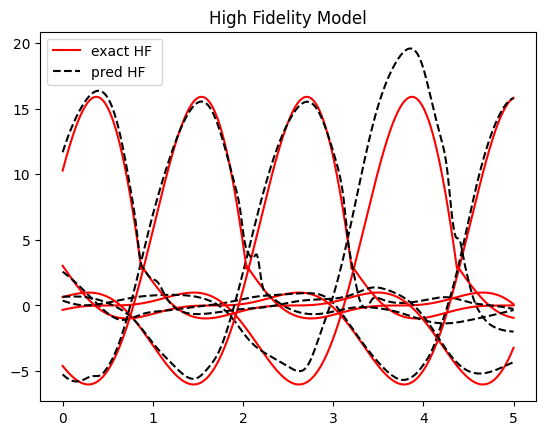

In [6]:
unique_values = np.unique(data["datatest"][:, 1])

plt.figure()

for val in unique_values:
    mask = data["datatest"][:, 1] == val
    x_values = data["datatest"][mask, 0]
    y_exact = data["modified_highfid"](x_values, val)
    y_pred = y_test[mask]

    plt.plot(x_values, y_exact, 'r', label=f'exact HF ' if val == unique_values[0] else "")
    plt.plot(x_values, y_pred, 'k--', label=f'pred HF ' if val == unique_values[0] else "")

plt.legend()
plt.title('High Fidelity Model')

plt.show()

# Prediction of a parameter 2 step nn

# definitivo

In [6]:
# introduction of a seed for reproducibility purposes
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

In [6]:
mean_prior = np.array([14.])
cov_prior = np.diag([1.])

sigma_noise_bounds = (0.05,0.15)
n_data_bounds = (30,50)
parameter = np.array([21.])
sigma_bounds = ( .5,1.5)



rwmh_scaling_bounds = (0.5,1.5)
rwmh_cov = (1,2)
rwmh_adaptive = True
iterations = 15
burnin = 10
n_chains = 2
algo = "AM"

module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

sigma_noise_MF, n_data_MF, sigma_MF, rwmh_scaling_MF= HPO_tinyDA(datahf=data["datatest"], 
                                                    mean_prior=mean_prior, 
                                                    cov_prior=cov_prior, 
                                                    Yhf=data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]), 
                                                    sigma_noise=sigma_noise_bounds, 
                                                    n_data=n_data_bounds,
                                                    parameters=parameter, 
                                                    sigma=sigma_bounds,
                                                    rwmh_scaling=rwmh_scaling_bounds, 
                                                    rwmh_cov=rwmh_cov, 
                                                    rwmh_adaptive=rwmh_adaptive, 
                                                    iterations=iterations, 
                                                    burnin=burnin, 
                                                    n_chains= n_chains, 
                                                    final_model=final_model,
                                                    levels=1, 
                                                    algo=algo, 
                                                    force_sequential=False)


|   iter    |  target   |  n_data   | rwmh_cov  |   sigma   | sigma_... |
-------------------------------------------------------------------------
Sampling 2 chains in parallel


2024-08-22 04:30:53,508	INFO worker.py:1788 -- Started a local Ray instance.


KeyboardInterrupt: 

Sampling chain 1/2


Running chain, α = 0.57:   0%|          | 6/1500 [00:00<03:00,  8.26it/s]c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.22: 100%|██████████| 1500/1500 [02:46<00:00,  9.03it/s]


Sampling chain 2/2


Running chain, α = 0.22: 100%|██████████| 1500/1500 [02:49<00:00,  8.86it/s]


      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  20.859  0.036  20.788   20.926      0.003    0.002     138.0      90.0   

    r_hat  
x0   1.02  
Estimated values are [20.859]
The difference between estimated values [0.141]



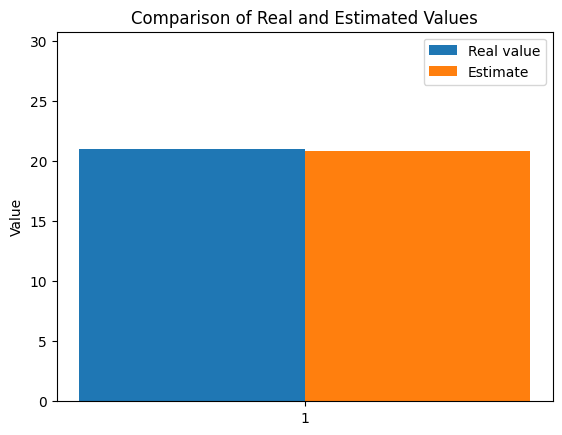

The function param_inverse took 351.177578 seconds.
Sampling chain 1/3


Running chain, α = 0.24: 100%|██████████| 1500/1500 [02:49<00:00,  8.86it/s]


Sampling chain 2/3


Running chain, α = 0.24: 100%|██████████| 1500/1500 [02:51<00:00,  8.77it/s]


Sampling chain 3/3


Running chain, α = 0.14: 100%|██████████| 1500/1500 [02:49<00:00,  8.84it/s]


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  9.609  0.025   9.567    9.658      0.002    0.001     164.0     154.0   

    r_hat  
x0   1.04  
Estimated values are [9.609]
The difference between estimated values [11.391]



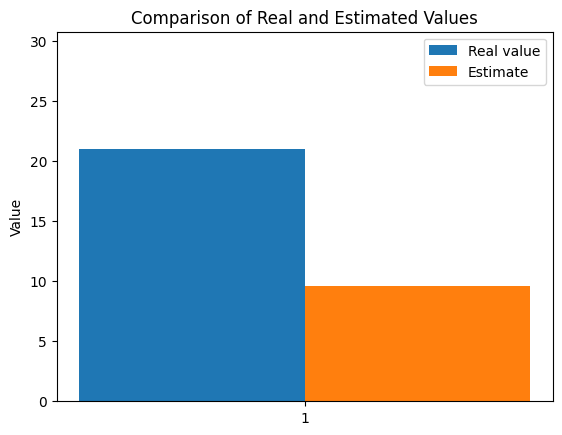

The function param_inverse took 524.586629 seconds.
Sampling chain 1/4


Running chain, α = 0.60:   0%|          | 4/1500 [00:00<02:50,  8.79it/s]c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.25: 100%|██████████| 1500/1500 [02:52<00:00,  8.69it/s]


Sampling chain 2/4


Running chain, α = 0.16: 100%|██████████| 1500/1500 [02:54<00:00,  8.60it/s]


Sampling chain 3/4


Running chain, α = 0.23: 100%|██████████| 1500/1500 [02:54<00:00,  8.61it/s]


Sampling chain 4/4


Running chain, α = 0.20: 100%|██████████| 1500/1500 [02:55<00:00,  8.56it/s]


      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  20.894  0.036  20.835   20.966      0.002    0.001     358.0     311.0   

    r_hat  
x0   1.03  
Estimated values are [20.894]
The difference between estimated values [0.106]



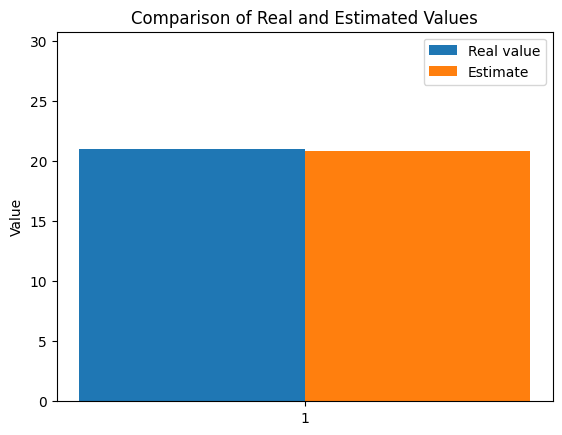

The function param_inverse took 698.353434 seconds.
Sampling chain 1/6


Running chain, α = 0.38:   1%|          | 12/1500 [00:01<02:57,  8.40it/s]c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.23: 100%|██████████| 1500/1500 [02:58<00:00,  8.40it/s]


Sampling chain 2/6


Running chain, α = 0.18: 100%|██████████| 1500/1500 [02:58<00:00,  8.39it/s]


Sampling chain 3/6


...

Sampling chain 5/6


Running chain, α = 0.23: 100%|██████████| 1500/1500 [03:03<00:00,  8.16it/s]


Sampling chain 6/6


Running chain, α = 0.19: 100%|██████████| 1500/1500 [03:04<00:00,  8.11it/s]


      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  20.906  0.034  20.845   20.968      0.002    0.001     513.0     481.0   

    r_hat  
x0   1.02  
Estimated values are [20.906]
The difference between estimated values [0.094]



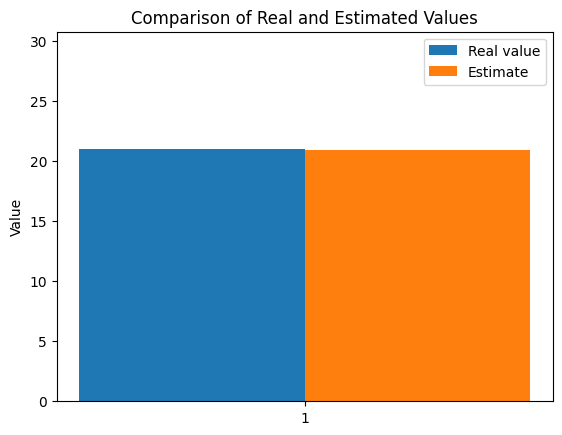

The function param_inverse took 1094.174434 seconds.
Sampling chain 1/8


Running chain, α = 0.21:   1%|          | 13/1500 [00:01<02:45,  8.96it/s]c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.25: 100%|██████████| 1500/1500 [03:07<00:00,  8.00it/s]


Sampling chain 2/8


Running chain, α = 0.33: 100%|██████████| 1500/1500 [03:10<00:00,  7.89it/s]


Sampling chain 3/8


...

Sampling chain 7/8


Running chain, α = 0.23: 100%|██████████| 1500/1500 [03:19<00:00,  7.52it/s]


Sampling chain 8/8


Running chain, α = 0.31: 100%|██████████| 1500/1500 [03:16<00:00,  7.62it/s]


      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  20.899  0.037  20.835   20.974      0.001    0.001     645.0     527.0   

    r_hat  
x0   1.02  
Estimated values are [20.899]
The difference between estimated values [0.101]



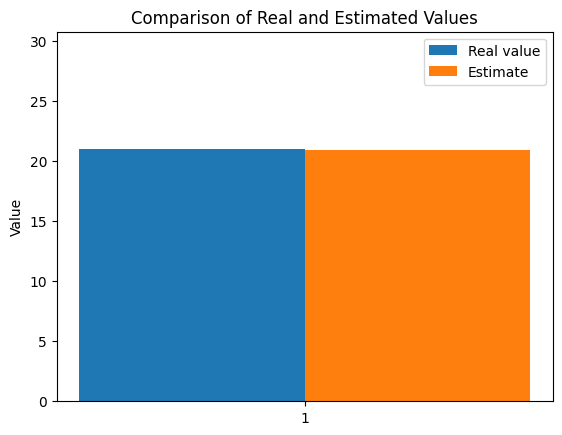

The function param_inverse took 1559.075665 seconds.
Sampling 2 chains in parallel


2024-08-21 21:08:15,719	INFO worker.py:1788 -- Started a local Ray instance.
(RemoteChain pid=1450852) c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp
(RemoteChain pid=1450852)   return np.exp(proposal_link.posterior - previous_link.posterior)


      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  20.901  0.037  20.831   20.967      0.003    0.002     146.0     169.0   

    r_hat  
x0   1.04  
Estimated values are [20.901]
The difference between estimated values [0.099]



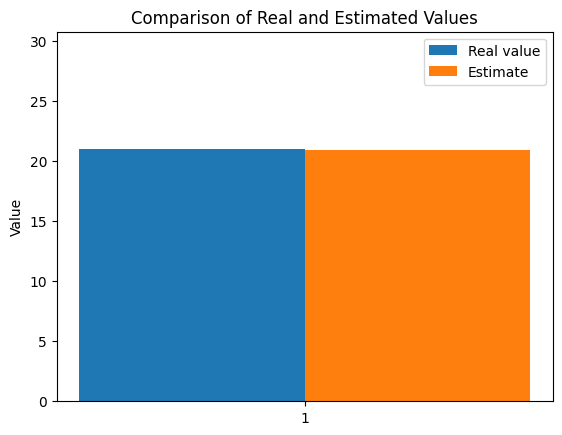

The function param_inverse took 372.263579 seconds.
Sampling 3 chains in parallel


2024-08-21 21:14:35,367	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.
(RemoteChain pid=1951708) c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp [repeated 2x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(RemoteChain pid=1951708)   return np.exp(proposal_link.posterior - previous_link.posterior) [repeated 2x across cluster]


      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  20.886  0.038  20.826   20.961      0.003    0.002     178.0     281.0   

    r_hat  
x0   1.02  
Estimated values are [20.886]
The difference between estimated values [0.114]



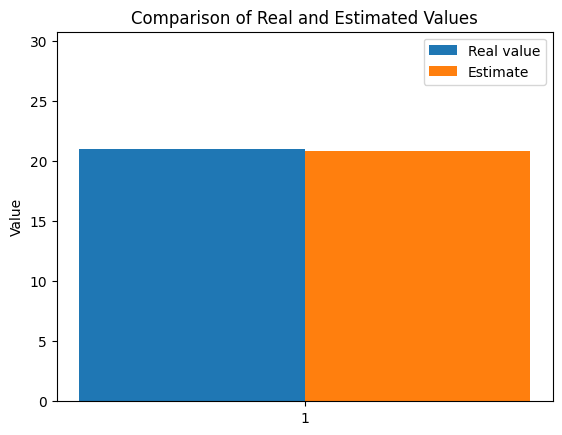

The function param_inverse took 405.014225 seconds.
Sampling 4 chains in parallel


2024-08-21 21:20:51,958	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.
(RemoteChain pid=3768612) c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp [repeated 3x across cluster]
(RemoteChain pid=3768612)   return np.exp(proposal_link.posterior - previous_link.posterior) [repeated 3x across cluster]


      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  20.907  0.035  20.847   20.973      0.002    0.001     354.0     291.0   

    r_hat  
x0   1.02  
Estimated values are [20.907]
The difference between estimated values [0.093]



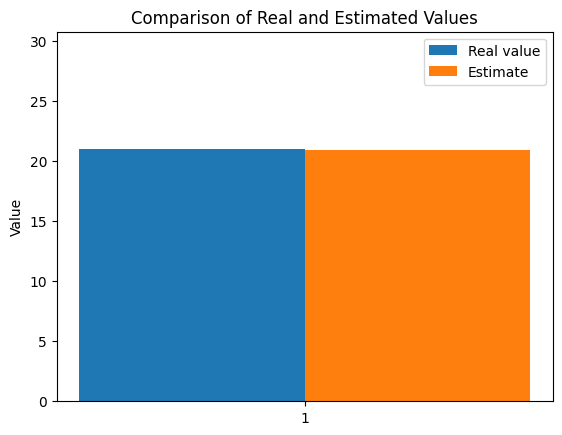

The function param_inverse took 411.758919 seconds.
Sampling 6 chains in parallel


2024-08-21 21:27:56,091	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.
(RemoteChain pid=4397000) c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp [repeated 4x across cluster]
(RemoteChain pid=4397000)   return np.exp(proposal_link.posterior - previous_link.posterior) [repeated 4x across cluster]
(RemoteChain pid=4396592) c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp [repeated 5x across cluster]
(RemoteChain pid=4396592)   return np.exp(proposal_link.posterior - previous_link.posterior) [repeated 5x across cluster]


      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  20.892  0.038  20.826    20.96      0.002    0.001     422.0     483.0   

    r_hat  
x0   1.02  
Estimated values are [20.892]
The difference between estimated values [0.108]



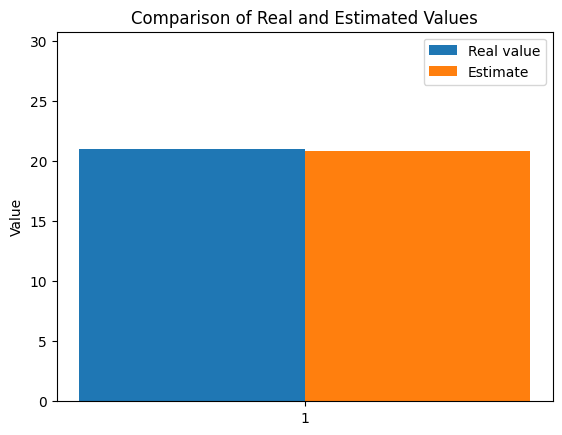

The function param_inverse took 487.197141 seconds.
Sampling 8 chains in parallel


2024-08-21 21:36:10,945	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.
(RemoteChain pid=699496) c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp
(RemoteChain pid=699496)   return np.exp(proposal_link.posterior - previous_link.posterior)
(RemoteChain pid=43092) c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp
(RemoteChain pid=43092)   return np.exp(proposal_link.posterior - previous_link.posterior)


      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  20.885  0.039  20.807    20.95      0.002    0.001     599.0     546.0   

    r_hat  
x0   1.02  
Estimated values are [20.885]
The difference between estimated values [0.115]



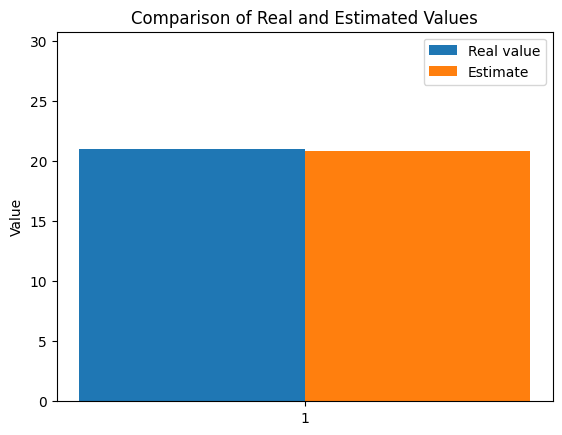

The function param_inverse took 579.912439 seconds.


In [10]:
mean_prior = np.array([14.])
cov_prior = np.diag([1.])

sigma_noise_bounds = np.array([0.15])
n_data_bounds = np.array([42])
parameter = np.array([21.])
sigma_bounds = np.array([0.5])



rwmh_scaling_bounds =  np.array([0.5])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 1500
burnin = 1000
num_chains = [2,3,4,6,8]
algo = "MH"


module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)
execution_times_seq = []
execution_times_par = []

for n_chains in num_chains:
    start_time = time.time()
    inferred_parameters, error, diagnostics= run_param_inverse(datahf=data["datatest"], 
                                                        mean_prior=mean_prior, 
                                                        cov_prior=cov_prior, 
                                                        Yhf=data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]), 
                                                        sigma_noise=sigma_noise_bounds, 
                                                        n_data=n_data_bounds,
                                                        parameters=parameter, 
                                                        sigma=sigma_bounds,
                                                        rwmh_scaling=rwmh_scaling_bounds, 
                                                        rwmh_cov=rwmh_cov, 
                                                        rwmh_adaptive=rwmh_adaptive, 
                                                        iterations=iterations, 
                                                        burnin=burnin, 
                                                        n_chains= n_chains, 
                                                        final_model=final_model,
                                                        levels=1, 
                                                        algo=algo, 
                                                        force_sequential=True)
    end_time = time.time()  
    execution_times_seq.append(end_time - start_time)

for n_chains in num_chains:
    start_time = time.time()
    inferred_parameters, error, diagnostics= run_param_inverse(datahf=data["datatest"], 
                                                        mean_prior=mean_prior, 
                                                        cov_prior=cov_prior, 
                                                        Yhf=data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]), 
                                                        sigma_noise=sigma_noise_bounds, 
                                                        n_data=n_data_bounds,
                                                        parameters=parameter, 
                                                        sigma=sigma_bounds,
                                                        rwmh_scaling=rwmh_scaling_bounds, 
                                                        rwmh_cov=rwmh_cov, 
                                                        rwmh_adaptive=rwmh_adaptive, 
                                                        iterations=iterations, 
                                                        burnin=burnin, 
                                                        n_chains= n_chains, 
                                                        final_model=final_model,
                                                        levels=1, 
                                                        algo=algo, 
                                                        force_sequential=False)
    end_time = time.time()  
    execution_times_par.append(end_time - start_time)


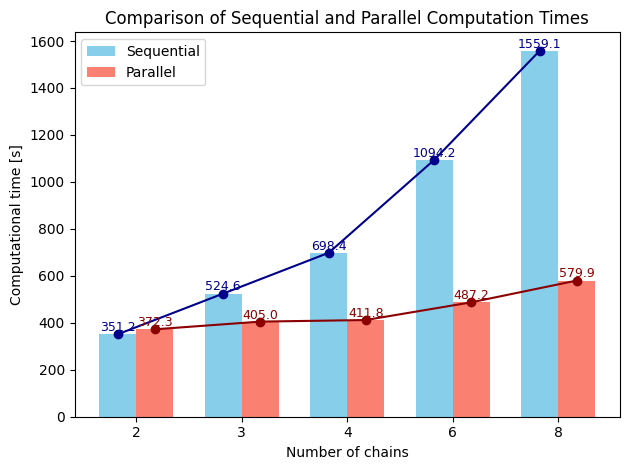

In [15]:
# Indici per le barre
indici = np.arange(len(elements))

# Larghezza delle barre
larghezza_barra = 0.35

# Creazione della figura e degli assi
fig, ax = plt.subplots()

# Barre per ciascuna lista
barre1 = ax.bar(indici - larghezza_barra/2, sequential, larghezza_barra, label='Sequential', color='skyblue')
barre2 = ax.bar(indici + larghezza_barra/2, parallel, larghezza_barra, label='Parallel', color='salmon')

# Aggiunta delle linee di connessione per "Sequential" con colore personalizzato
ax.plot(indici - larghezza_barra/2, sequential, color='darkblue', linestyle='-', marker='o')

# Aggiunta delle linee di connessione per "Parallel" con colore personalizzato
ax.plot(indici + larghezza_barra/2, parallel, color='darkred', linestyle='-', marker='o')

# Aggiunta dei valori in cima a ciascuna barra con una cifra decimale
for i in range(len(elements)):
    ax.text(indici[i] - larghezza_barra/2, sequential[i] + 0.5, f'{sequential[i]:.1f}', ha='center', va='bottom', fontsize=9, color='darkblue')
    ax.text(indici[i] + larghezza_barra/2, parallel[i] + 0.5, f'{parallel[i]:.1f}', ha='center', va='bottom', fontsize=9, color='darkred')

# Etichette e titolo
ax.set_xlabel('Number of chains')
ax.set_ylabel('Computational time [s]')
ax.set_title('Comparison of Sequential and Parallel Computation Times')

# Etichette per asse X
ax.set_xticks(indici)
ax.set_xticklabels(elements)

# Aggiunta della legenda
ax.legend()

# Layout più compatto
plt.tight_layout()

# Mostra il grafico
plt.show()

In [18]:
sigma_noise_MF, n_data_MF, sigma_MF, rwmh_scaling_MF

(0.15, 42, 0.5, 0.5)

Sample 1500 / 1500

Average acceptance rate: 0.05357142857142857 MCMC scale: 0.5971858695316994 

Mean values: [3.56006593]
Sample 1500 / 1500

Average acceptance rate: 0.04214285714285714 MCMC scale: 0.5610273369708628 

Mean values: [9.61566889]
ESS values = 2.9706358820049985
Error wrt true parameters: [0.68629203]
The difference between estimated values [14.41213259]



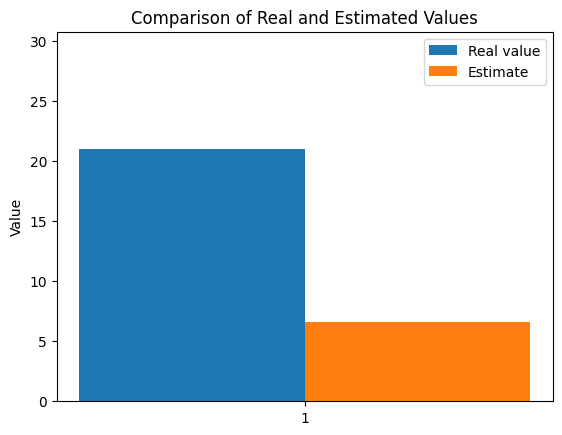

The function inverse_cuqi took 340.874362 seconds.
Parameters used: sd_noise=0.15, proposal_sd=0.5, n_data=42, scale=1.5
Sample 1500 / 1500

Average acceptance rate: 0.039285714285714285 MCMC scale: 0.5571571810333815 

Mean values: [9.61563325]
Sample 1500 / 1500

Average acceptance rate: 0.035 MCMC scale: 0.5456227844783869 

Mean values: [9.61377609]
Sample 1500 / 1500

Average acceptance rate: 0.041428571428571426 MCMC scale: 0.5735869334071648 

Mean values: [3.38602076]
ESS values = 4.696568941745494
Error wrt true parameters: [0.64102492]
The difference between estimated values [13.4615233]



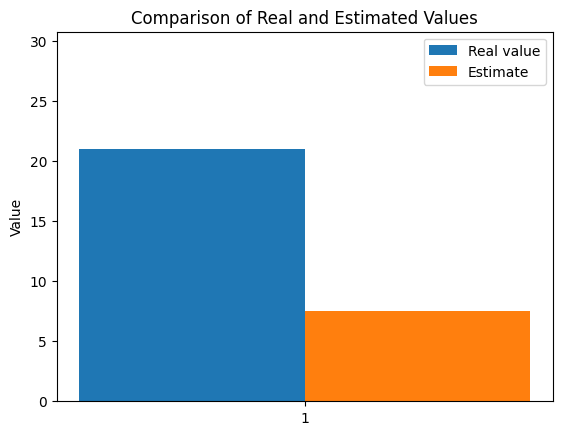

The function inverse_cuqi took 531.597716 seconds.
Parameters used: sd_noise=0.15, proposal_sd=0.5, n_data=42, scale=1.5
Sample 1500 / 1500

Average acceptance rate: 0.039285714285714285 MCMC scale: 0.5723003858737089 

Mean values: [3.40302875]
Sample 1500 / 1500

Average acceptance rate: 0.045 MCMC scale: 0.5792891798156609 

Mean values: [3.41784201]
Sample 1500 / 1500

Average acceptance rate: 0.032857142857142856 MCMC scale: 0.5605853906405993 

Mean values: [3.400707]
Sample 1500 / 1500

Average acceptance rate: 0.04 MCMC scale: 0.5762246089095965 

Mean values: [3.39662341]
ESS values = 189.37378918159243
Error wrt true parameters: [0.83787856]
The difference between estimated values [17.59544971]



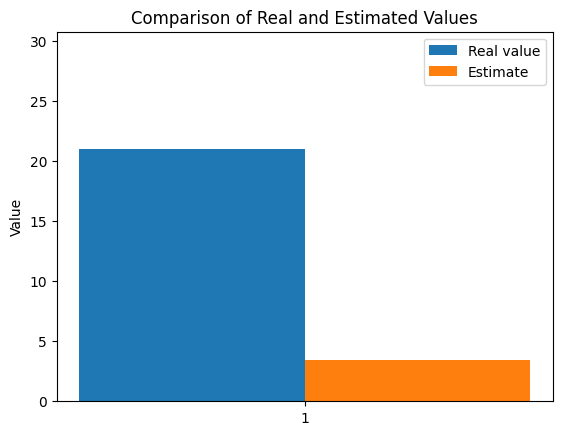

The function inverse_cuqi took 714.117057 seconds.
Parameters used: sd_noise=0.15, proposal_sd=0.5, n_data=42, scale=1.5
Sample 1500 / 1500

Average acceptance rate: 0.03642857142857143 MCMC scale: 0.5805632820385974 

Mean values: [3.39245418]
Sample 1500 / 1500

Average acceptance rate: 0.045714285714285714 MCMC scale: 0.5786326617416202 

Mean values: [9.61222817]
Sample 1500 / 1500

Average acceptance rate: 0.032857142857142856 MCMC scale: 0.5657228930735434 

Mean values: [3.38475271]
Sample 1500 / 1500

Average acceptance rate: 0.04428571428571428 MCMC scale: 0.5882594452988127 

Mean values: [9.60713865]
Sample 1500 / 1500

Average acceptance rate: 0.035 MCMC scale: 0.569317461046555 

Mean values: [3.38179749]
Sample 1500 / 1500

Average acceptance rate: 0.052142857142857144 MCMC scale: 0.5972173700846403 

Mean values: [9.61401955]
ESS values = 9.182461113676368
Error wrt true parameters: [0.69053658]
The difference between estimated values [14.50126821]



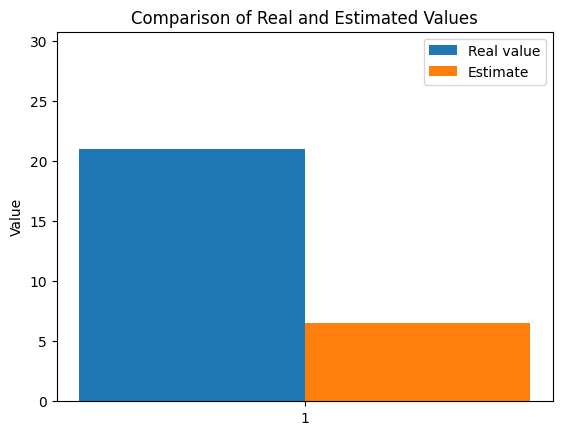

The function inverse_cuqi took 1136.126931 seconds.
Parameters used: sd_noise=0.15, proposal_sd=0.5, n_data=42, scale=1.5
Sample 1500 / 1500

Average acceptance rate: 0.04857142857142857 MCMC scale: 0.5920094525826206 

Mean values: [3.54387348]
Sample 1500 / 1500

Average acceptance rate: 0.04357142857142857 MCMC scale: 0.5711123428559192 

Mean values: [9.63017552]
Sample 1500 / 1500

Average acceptance rate: 0.04428571428571428 MCMC scale: 0.5805668027963842 

Mean values: [3.43103514]
Sample 1500 / 1500

Average acceptance rate: 0.045714285714285714 MCMC scale: 0.5757119121579788 

Mean values: [9.61917485]
Sample 1500 / 1500

Average acceptance rate: 0.045714285714285714 MCMC scale: 0.5674791026297177 

Mean values: [9.61926538]
Sample 1500 / 1500

Average acceptance rate: 0.04 MCMC scale: 0.5890020439938756 

Mean values: [3.39164589]
Sample 1500 / 1500

Average acceptance rate: 0.039285714285714285 MCMC scale: 0.5967694560410026 

Mean values: [3.39031701]
Sample 1500 / 1500

Av

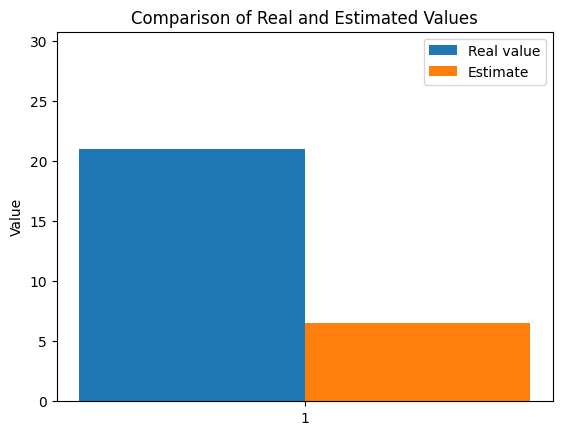

The function inverse_cuqi took 1688.993042 seconds.
Parameters used: sd_noise=0.15, proposal_sd=0.5, n_data=42, scale=1.5
ESS values = 76.82894994679492
Error wrt true parameters: [0.54153127]
The difference between estimated values [11.3721566]



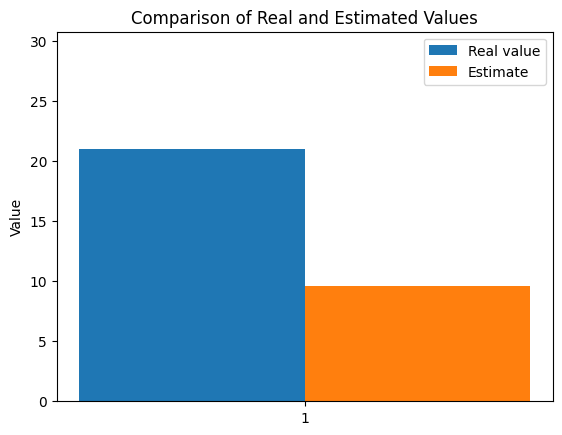

The function inverse_cuqi took 275.587922 seconds.
Parameters used: sd_noise=0.15, proposal_sd=0.5, n_data=42, scale=1.5
ESS values = 4.89579072917655
Error wrt true parameters: [0.73979848]
The difference between estimated values [15.53576801]



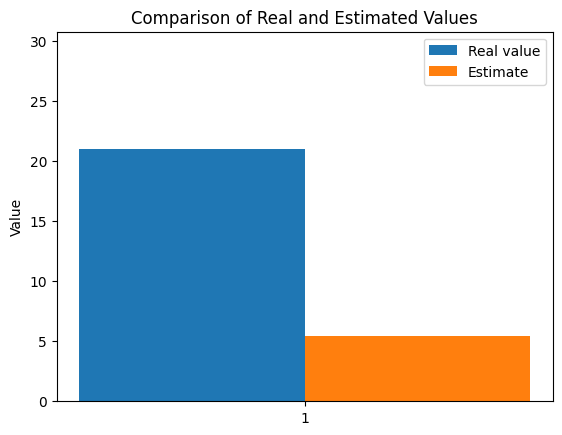

The function inverse_cuqi took 317.477065 seconds.
Parameters used: sd_noise=0.15, proposal_sd=0.5, n_data=42, scale=1.5
ESS values = 7.014266360380335
Error wrt true parameters: [0.61621403]
The difference between estimated values [12.94049464]



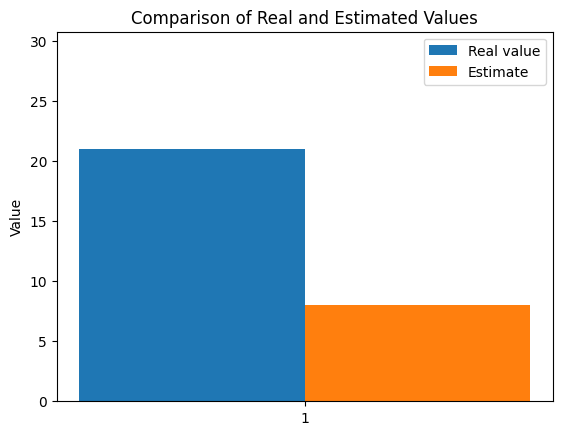

The function inverse_cuqi took 365.970921 seconds.
Parameters used: sd_noise=0.15, proposal_sd=0.5, n_data=42, scale=1.5
ESS values = 9.328836225878522
Error wrt true parameters: [0.69026057]
The difference between estimated values [14.49547194]



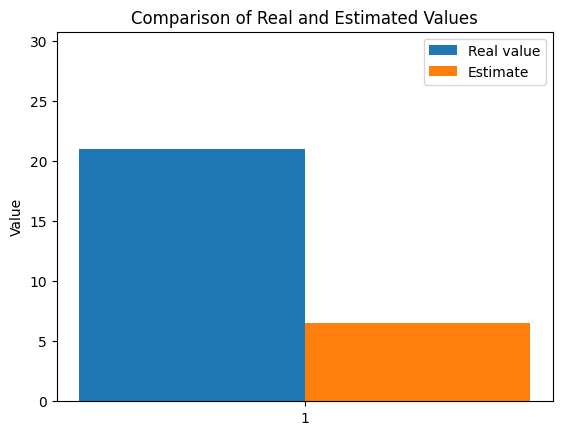

The function inverse_cuqi took 418.788954 seconds.
Parameters used: sd_noise=0.15, proposal_sd=0.5, n_data=42, scale=1.5
ESS values = 13.081352793742791
Error wrt true parameters: [0.65323833]
The difference between estimated values [13.71800497]



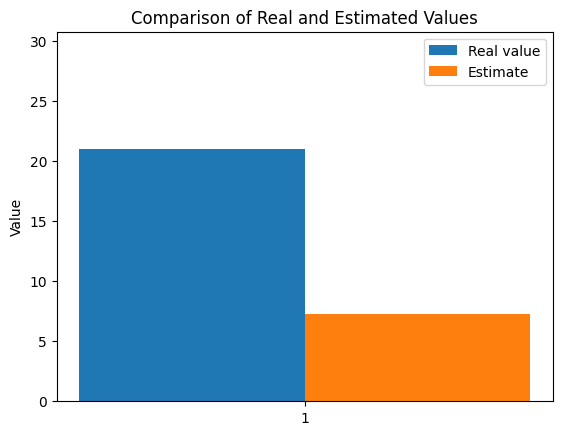

The function inverse_cuqi took 477.526982 seconds.
Parameters used: sd_noise=0.15, proposal_sd=0.5, n_data=42, scale=1.5


In [8]:
# Define inputs
mean_prior = np.array([14.])
cov_prior =1

Yhf = data["Yhf"]
sd_noise = 0.15
n_data =42
parameters = np.array([21.])
iterations = 1500
burnin = 100
num_chains = [2,3,4,6,8]
algo = "MH"

proposal_sd =0.5  # più piccolo, altrimenti scappa da previsione 
scaling = 1.5
adapt = True


module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure2.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)
execution_times_seq = []
execution_times_par = []
#x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times

for n_chains in num_chains:
    start_time = time.time()

    best_estimate, best_error, params_result=run_inverse_cuqi(
        data=data["datatest"],
        Yhf=data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]),
        mean_prior= mean_prior,
        parameters=parameters,
        iterations= iterations,
        burn_in= burnin,
        cov_prior= cov_prior,
        sd_noise=sd_noise,
        proposal_sd= proposal_sd,
        n_data=n_data,
        scale= scaling,
        adapt=adapt,
        number_chains= n_chains,
        algo=algo,
        fwd_model=final_model,
        parallel=False,

    ) 

    end_time = time.time()  
    execution_times_seq.append(end_time - start_time)

for n_chains in num_chains:
    start_time = time.time()

    best_estimate, best_error, params_result=run_inverse_cuqi(
        data=data["datatest"],
        Yhf=data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]),
        mean_prior= mean_prior,
        parameters=parameters,
        iterations= iterations,
        burn_in= burnin,
        cov_prior= cov_prior,
        sd_noise=sd_noise,
        proposal_sd= proposal_sd,
        n_data=n_data,
        scale= scaling,
        adapt=adapt,
        number_chains= n_chains,
        algo=algo,
        fwd_model=final_model,
        parallel=True,

    )


    end_time = time.time()  
    execution_times_par.append(end_time - start_time) 

In [11]:
elements=num_chains
sequential=execution_times_seq
parallel=execution_times_par

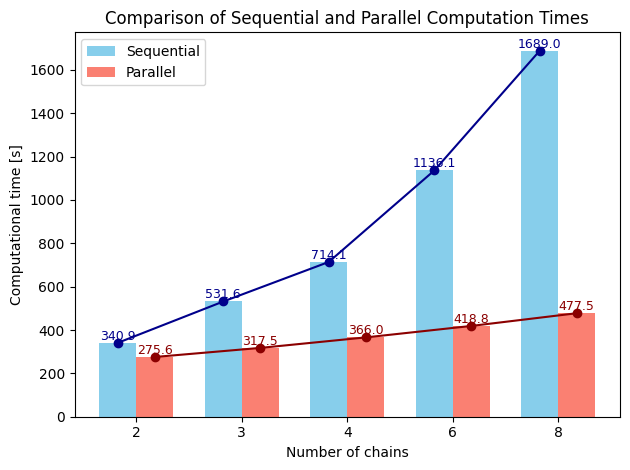

In [12]:
# Indici per le barre
indici = np.arange(len(elements))

# Larghezza delle barre
larghezza_barra = 0.35

# Creazione della figura e degli assi
fig, ax = plt.subplots()

# Barre per ciascuna lista
barre1 = ax.bar(indici - larghezza_barra/2, sequential, larghezza_barra, label='Sequential', color='skyblue')
barre2 = ax.bar(indici + larghezza_barra/2, parallel, larghezza_barra, label='Parallel', color='salmon')

# Aggiunta delle linee di connessione per "Sequential" con colore personalizzato
ax.plot(indici - larghezza_barra/2, sequential, color='darkblue', linestyle='-', marker='o')

# Aggiunta delle linee di connessione per "Parallel" con colore personalizzato
ax.plot(indici + larghezza_barra/2, parallel, color='darkred', linestyle='-', marker='o')

# Aggiunta dei valori in cima a ciascuna barra con una cifra decimale
for i in range(len(elements)):
    ax.text(indici[i] - larghezza_barra/2, sequential[i] + 0.5, f'{sequential[i]:.1f}', ha='center', va='bottom', fontsize=9, color='darkblue')
    ax.text(indici[i] + larghezza_barra/2, parallel[i] + 0.5, f'{parallel[i]:.1f}', ha='center', va='bottom', fontsize=9, color='darkred')

# Etichette e titolo
ax.set_xlabel('Number of chains')
ax.set_ylabel('Computational time [s]')
ax.set_title('Comparison of Sequential and Parallel Computation Times')

# Etichette per asse X
ax.set_xticks(indici)
ax.set_xticklabels(elements)

# Aggiunta della legenda
ax.legend()

# Layout più compatto
plt.tight_layout()

# Mostra il grafico
plt.show()

In [6]:
# Define inputs
mean_prior = np.array([11.])
cov_prior = np.diag([1.])

Yhf = data["Yhf"]
sd_noise = (0.05,0.1)
n_data = (30,50)
parameters = np.array([0.])

iterations = 200
burnin = 12
number_chains = 2
algo = "MH"

proposal_sd = (.5,1.)    # più piccolo, altrimenti scappa da previsione 
scaling = (1.,2.)
adapt = True


module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure2.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

#x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times

best_estimate, best_error, best_sd_noise, best_proposal_sd, best_n_data, best_scale=HPO_cuqi(
    data= data["xhf"],
    Yhf=data["Yhf"],
    mean_prior= mean_prior,
    parameters=parameters,
    iterations= iterations,
    burn_in= burnin,
    cov_prior= cov_prior,
    sd_noise=sd_noise,
    proposal_sd= proposal_sd,
    n_data=n_data,
    scale= scaling,
    adapt=adapt,
    number_chains= number_chains,
    algo=algo,
    fwd_model=final_model,
    parallel=False,
    init_points = 5,
    n_iter = 25
) 



|   iter    |  target   |  n_data   | propos... |   scale   | sd_noise  |
-------------------------------------------------------------------------
Sample 200 / 200

Average acceptance rate: 0.2393617021276596 MCMC scale: 1 

Mean values: [15.01099539]
Sample 62 / 200

c:\Users\Giacomo\miniconda3\Lib\site-packages\cuqi\model\_model.py:14: SyntaxWarning: invalid escape sequence '\m'
  """Generic model defined by a forward operator.


KeyboardInterrupt: 

In [ ]:
best_estimateHF, best_errorHF, params_resultHF=run_simulation_cuqi(
    data=data,
    mean_prior=mean_prior,
    parameters=parameters,
    iterations=iterations,
    burn_in=burnin,
    cov_prior=cov_prior,
    sd_noise=sd_noise,  
    adapt=adapt,
    proposal_sd=proposal_sd,
    number_chains=number_chains,
    algo=algo,
    n_data=n_data,
    scale=scaling,
    fwd_model=modelHF,
    parallel=False
) 

In [ ]:
best_estimateLF, best_errorLF, params_resultLF=run_simulation_cuqi(
    data=data,
    mean_prior=mean_prior,
    parameters=parameters,
    iterations=iterations,
    burn_in=burnin,
    cov_prior=cov_prior,
    sd_noise=sd_noise,  
    adapt=adapt,
    proposal_sd=proposal_sd,
    number_chains=number_chains,
    algo=algo,
    n_data=n_data,
    scale=scaling,
    fwd_model=modelLF,
    parallel=False
) 

In [ ]:

best_estimateMF_par, best_errorMF_par, params_resultMF_par=run_simulation_cuqi(
    data=data,
    mean_prior=mean_prior,
    parameters=parameters,
    iterations=iterations,
    burn_in=burnin,
    cov_prior=cov_prior,
    sd_noise=sd_noise,  
    adapt=adapt,
    proposal_sd=proposal_sd,
    number_chains=number_chains,
    algo=algo,
    n_data=n_data,
    scale=scaling,
    fwd_model=final_model,
    parallel=False
) 



In [ ]:
best_estimateHF_par, best_errorHF_par, params_resultHF_par=run_simulation_cuqi(
    data=data,
    mean_prior=mean_prior,
    parameters=parameters,
    iterations=iterations,
    burn_in=burnin,
    cov_prior=cov_prior,
    sd_noise=sd_noise,  
    adapt=adapt,
    proposal_sd=proposal_sd,
    number_chains=number_chains,
    algo=algo,
    n_data=n_data,
    scale=scaling,
    fwd_model=modelHF,
    parallel=True
) 

# _----------------------------------------

Sampling chain 1/2


Running chain, α_c = 0.407, α_f = 0.20: 100%|██████████| 30/30 [00:02<00:00, 10.73it/s]


Sampling chain 2/2


Running chain, α_c = 0.356, α_f = 0.17: 100%|██████████| 30/30 [00:02<00:00, 11.21it/s]
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [6.151]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  6.151  0.169   5.903    6.315      0.083    0.064       4.0       6.0   

    r_hat  
x0   2.95  
The difference between estimated values [13.849]



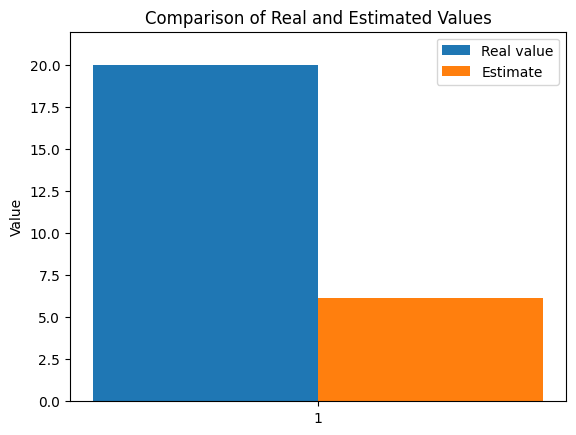

The function param_inverse took 6.495603 seconds.
Sampling chain 1/2


Running chain, α_c = 0.254, α_f = 0.07: 100%|██████████| 30/30 [00:02<00:00, 11.39it/s]


Sampling chain 2/2


Running chain, α_c = 0.322, α_f = 0.20: 100%|██████████| 30/30 [00:03<00:00,  9.12it/s]
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


Estimated values are [5.891]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.891  0.327   5.571    6.263      0.163    0.125       4.0       4.0   

    r_hat  
x0   4.51  
The difference between estimated values [14.109]



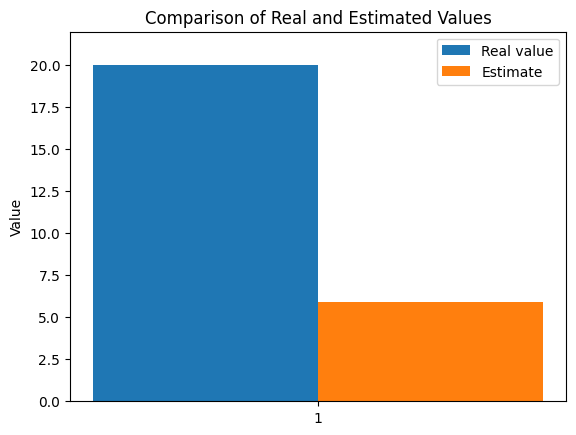

The function param_inverse took 7.154162 seconds.
Sampling chain 1/2


Running chain, α_c = 0.364, α_f = 0.17:  17%|█▋        | 5/30 [00:00<00:03,  6.98it/s]


KeyboardInterrupt: 

In [7]:
mean_prior = np.array([7.])
cov_prior = np.diag([1.])

sigma_noise = [0.05,0.1]
n_data = [50,30,10]
parameters = np.array([20.])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 30
burnin = 15
n_chains = 2
algo = "MH"

module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

# ricorda che i primi due non vanno bene in qualunque caso
estimateMF, errorMF,param_resultsMF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo, levels=2, force_sequential=True)

estimateHF, errorHF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, modelHF,algo)


